# Persistent Contrastive Divergence Algorithm

In [1]:
# Check for all needed packages
import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl
    mkl.set_num_threads(2)
except ImportError:
    print("Intel Math Kernel Library (MKL) does not always work on every machine. "
          "Continuing without `mkl`.")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [3]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1)


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)
def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos:(pos + size)] for pos in range(0, len(seq), size)])

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = examples[r, c]

    return img_matrix

def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

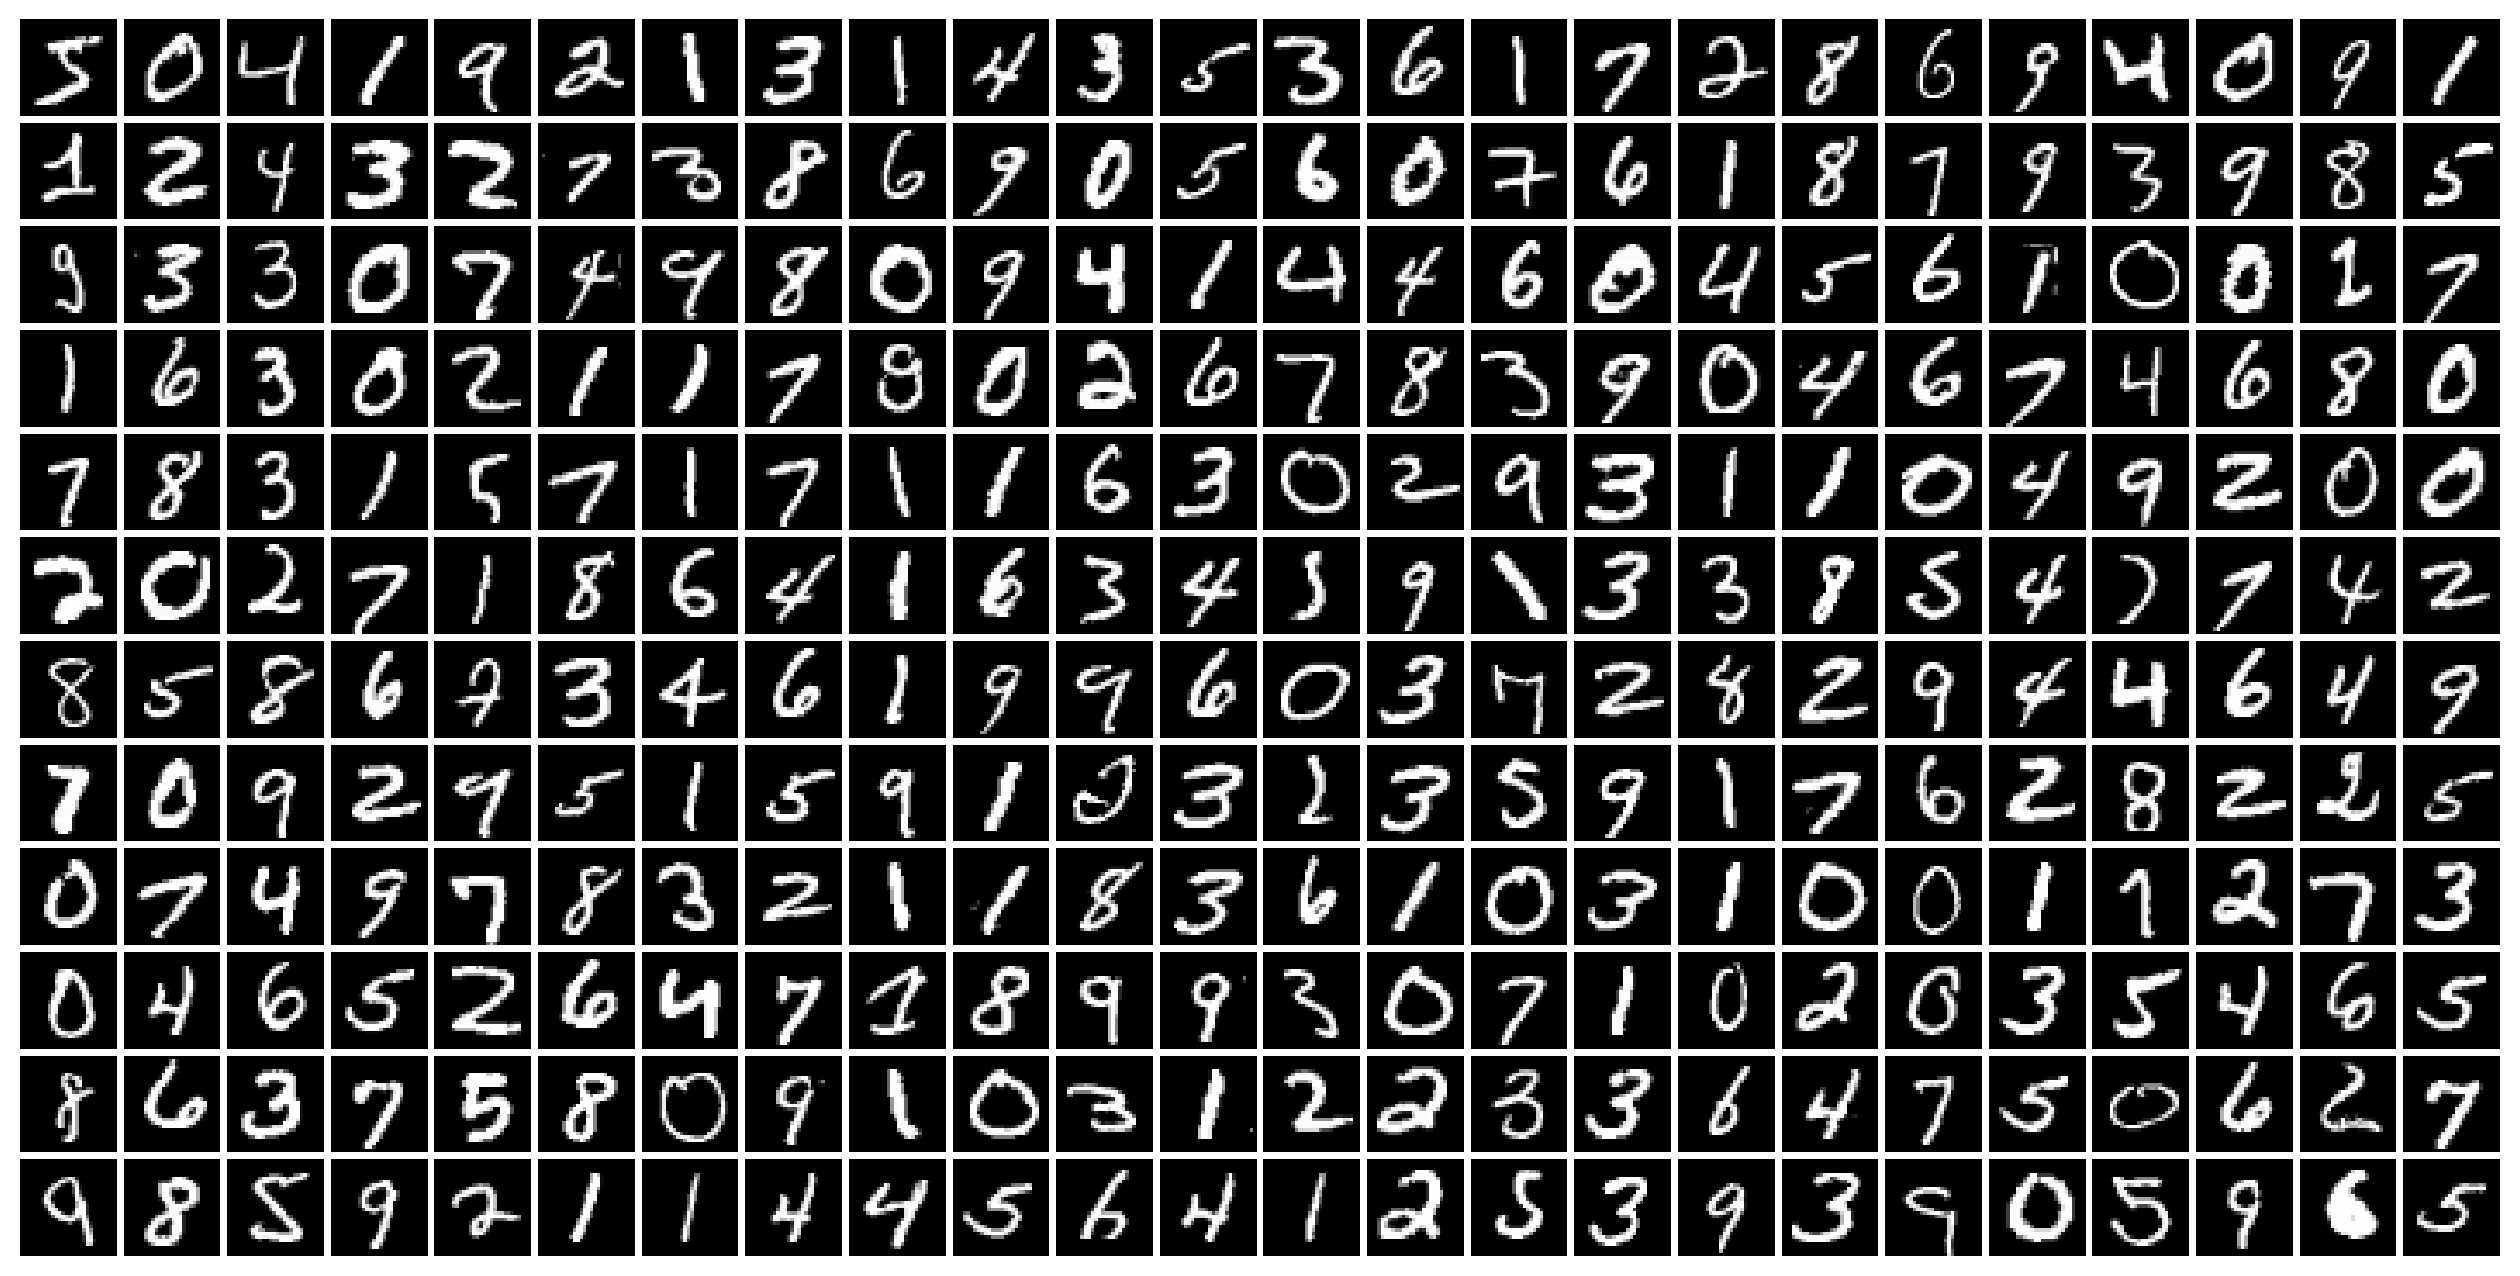

In [4]:
from mnists import MNIST
mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28 # [px]

def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], shape=shape)

mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [5]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Applies the sigmoid (logistic) activation function element-wise.

    Squashes each value in `x` to the range (0, 1), which is
    interpreted as an activation probability in the RBM context.
    """
    return 1.0 / (1.0 + np.exp(-x))

class RestrictedBoltzmanMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
        pc_count:      Number of how many hidden negative phases shall be preserved.
    """
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float,
        pc_count: int = None
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.pc_count = pc_count
        
        self.reset()
    
    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, 
            size=(self.visible_size + 1, self.hidden_size + 1),
        ).astype(np.float32)
        self.W[:, -1] = 0.0 # zero hidden-bias weights
        self.W[-1, :] = 0.0 # zero visible-bias weights
        self.PC = None if self.pc_count is None else append_ones(zeros(self.pc_count, self.hidden_size))

In [20]:
def reconstruction_error(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """
    observations_count = minibatch.shape[0]

    # hidden probabilities
    hidden = sigmoid(minibatch @ rbm.W)
    hidden[:, -1] = 1.0  # bias unit

    # visible reconstruction probabilities
    visible = sigmoid(hidden @ rbm.W.T)[:, :-1]

    error = np.sum((minibatch[:, :-1] - visible) ** 2) / observations_count
    return float(error)

### [EN] Description of the Contrastive Divergence algorithm

$\newcommand{\vect}[1]{\mathbf{#1}}$
In an RBM network, the gradient of the cost function with respect to the weights is given by:

$\frac{\delta}{\delta w_{ij}} -\log P(\vect{v}) = -\mathbf{E}[v_i h_j \vert \vect{v}] + \mathbf{E}[v_i h_j]$

#### Positive phase — corresponds to the $\mathbf{E}[v_i h_j \vert \vect{v}]$ term

This part of the gradient is computed by calculating the products $v_i h_j$ between the elements of the observation vector ($v_i$) and the activation probabilities in the hidden layer ($h_j$). This operation can be written in vectorised form as:

$\nabla_P = \vect{v}^T\sigma(\vect{vW})$

#### Negative phase — corresponds to the $\mathbf{E}[v_i h_j]$ term

We start from the hidden-layer activation probabilities computed during the positive phase and use them to draw a sample of hidden-layer activations:

$\vect{h} = \sigma (\vect{vW}) > [rand_1, rand_2, \dots, rand_m]$

We then draw a sample of visible-layer activations:

$\vect{v}_1 = \sigma (\vect{hW}^T) > [rand_1, rand_2, \dots, rand_n]$

To obtain the RBM *fantasy*, the above samples are drawn (alternately) $k$ times, where $k$ is the parameter of the CD-*k* algorithm:

$\vect{h}_{k-1} = \sigma (\vect{v}_{k-1}\vect{W}) > [rand_1, rand_2, \dots, rand_m]$,  
$\vect{v}_k = \sigma (\vect{h}_{k-1}\vect{W}^T) > [rand_1, rand_2, \dots, rand_n]$

The negative part of the gradient is computed by calculating the products $v_{k_i} h_j$ between the elements of the RBM *fantasy* vector ($v_{k_i}$) and the hidden-layer activation probabilities computed for that *fantasy* ($h_j$). This operation can be written in vectorised form as:

$\nabla_N = \vect{v}_k^T\sigma(\vect{v}_k\vect{W})$

#### RBM weight matrix update

Training is performed via stochastic gradient descent:

$\phi_{t+1} \leftarrow \phi_t - \epsilon \nabla$

which for the RBM gradient gives:

$W_{t+1} \leftarrow W_t + \epsilon \nabla_P - \epsilon \nabla_N$

### [PL] Algorytm Contrastive Divergence

$\renewcommand{\vect}[1]{\mathbf{#1}}$
W sieci RBM gradient funkcji kosztu względem wag wyznaczamy zgodnie ze wzorem:

$\frac{\delta}{\delta w_{ij}} -\log P(\vect{v}) = -\mathbf{E}[v_i h_j \vert \vect{v}] + \mathbf{E}[v_i h_j]$

#### Faza pozytywna - odpowiada za część $\mathbf{E}[v_i h_j \vert \vect{v}]$

Tą część gradientu wyznaczamy przez wyliczenie iloczynów $v_i h_j$ pomiędzy elementami wektora obserwacji ($v_i$) a prawdopodobieństwami aktywacji w warstwie ukrytej ($h_j$). Operację tą możemy zapisać w postaci zwektoryzowanej jako:

$\nabla_P = \vect{v}^T\sigma(\vect{vW})$

#### Faza negatywna - odpowiada za część $\mathbf{E}[v_i h_j]$

Rozpoczynamy od prawdopodobieństw aktywacji neuronów w warstwie ukrytej, które zostały wyznaczone w fazie pozytywnej. Na ich podstawie losujemy próbkę aktywacji w warstwie ukrytej:

$\vect{h} = \sigma (\vect{vW}) > [rand_1, rand_2, \dots, rand_m]$

Następnie losujemy próbkę aktywacji w warstwie widocznej:

$\vect{v}_1 = \sigma (\vect{hW}^T) > [rand_1, rand_2, \dots, rand_n]$

Aby wyznaczyć *fantazję* sieci RBM, powyższe próbki losujemy (naprzemiennie) $k$ razy (gdzie $k$ to parametr algorytmu CD-*k*):

$\vect{h}_{k-1} = \sigma (\vect{v}_{k-1}\vect{W}) > [rand_1, rand_2, \dots, rand_m]$, 
$\vect{v}_k = \sigma (\vect{h}_{k-1}\vect{W}^T) > [rand_1, rand_2, \dots, rand_n]$

Część negatywną gradientu wyznaczamy poprzez wyliczenie iloczynów $v_{k_i} h_j$ pomiędzy elementami wektora *fantazji* RBM ($v_{k_i}$) a prawdopodobieństwami aktywacji w warstwie ukrytej wyliczonymi dla tejże *fantazji* ($h_j$). Operację tą możemy zapisać w postaci zwektoryzowanej jako:

$\nabla_N = \vect{v}_k^T\sigma(\vect{v}_k\vect{W})$


#### Aktualizacja macierzy wag RBM

Uczymy stochastycznym spadkiem wzdłuż gradientu:

$\phi_{t+1} \leftarrow \phi_t - \epsilon \nabla$

co dla gradientu RBM daje:

$W_{t+1} \leftarrow W_t + \epsilon \nabla_P - \epsilon \nabla_N$

## CD-k implementation

In [21]:
def bernoulli_sample(prob: np.ndarray) -> np.ndarray:
    """
    Samples Bernoulli activations from probabilities.
    """
    return (prob > rand(*prob.shape)).astype(np.float32)

In [22]:
def cdk(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Performs a single Contrastive Divergence (CD-k) weight update in-place.
    """
    observations_count = minibatch.shape[0]

    # --- Initialize
    positive_visible = minibatch

    # Positive hidden probabilities
    positive_hidden = sigmoid(positive_visible @ rbm.W)
    positive_hidden[:, -1] = 1.0  # bias

    # Positive phase gradient
    positive_grad = positive_visible.T @ positive_hidden

    # Start negative phase from sampled hidden states
    negative_hidden = bernoulli_sample(positive_hidden)
    negative_hidden[:, -1] = 1.0

    for step in range(k):
        # Sample visible from hidden
        negative_visible_probs = sigmoid(negative_hidden @ rbm.W.T)
        negative_visible = bernoulli_sample(negative_visible_probs)
        negative_visible[:, -1] = 1.0

        # Hidden probabilities conditioned on reconstructed visible
        negative_hidden_probs = sigmoid(negative_visible @ rbm.W)
        negative_hidden_probs[:, -1] = 1.0

        if step < k - 1:
            negative_hidden = bernoulli_sample(negative_hidden_probs)
            negative_hidden[:, -1] = 1.0

    # Negative phase gradient uses v_k and P(h|v_k)
    negative_grad = negative_visible.T @ negative_hidden_probs

    rbm.W += rbm.learning_rate * (
        positive_grad / observations_count - negative_grad / observations_count
    )

    # keep bias-bias weight unused
    rbm.W[-1, -1] = 0.0

## [EN] Persistent Contrastive Divergence Algorithm

$\renewcommand{\vect}[1]{\mathbf{#1}}$
The Persistent Contrastive Divergence (PCD) algorithm differs from the CD algorithm in the course of the negative phase. The positive phase in PCD proceeds in the same way as in the CD algorithm.

In PCD, the negative phase does not start from a training example, but from the state of the *virtual particles*, which was stored during the previous negative phase:

$\vect{h} = \vect{p}$,

where $\vect{p}$ is the matrix that stores the state of the *virtual particles*. After initializing the negative hidden state ($\vect{h}$), we start Gibbs sampling and determine the fantasy of the network ($\vect{v}_k$). Next, we store the new state of the virtual particles:

$\vect{p} = \sigma (\vect{v}_k\vect{W}) > [rand_1, rand_2, \dots, rand_m]$.

Finally, we update the RBM weights. The weight update proceeds in the same way as in the CD algorithm.

## [PL] Algorytm Persistent Contrastive Divergence

$\renewcommand{\vect}[1]{\mathbf{#1}}$
Algorytm Persistent Contrastive Divergence (PCD) różni się od algorytmu CD przebiegiem fazy negatywnej. Faza pozytywna przebiega w PCD tak samo jak w algorytmie CD.

W PCD faza negatywna rozpoczyna się od nie od przykładu uczącego, lecz od stanu *wirtualnych cząstek*, który został został zapamiętany w poprzedniej fazie negatywnej:

$\vect{h} = \vect{p}$,

gdzie $\vect{p}$ to macierz przechowująca stan *wirtualnych cząstek*. Po inicjalizacji negatywnego stanu ukrytego ($\vect{h}$) rozpoczynamy próbkowanie Gibbsa i wyznaczamy fantazję sieci ($\vect{v}_k$). Następnie zapamiętujemy nowy stan wirtualnych cząstek:

$\vect{p} = \sigma (\vect{v}_k\vect{W}) > [rand_1, rand_2, \dots, rand_m]$.

Na koniec aktualizujemy wagi RBM. Aktualizacja wag przebiega tak samo jak w algorytmie CD.

## PCD implementation

In [23]:
def pcd(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Perform one Persistent Contrastive Divergence (PCD-k) update step on the RBM.
    """
    observations_count = minibatch.shape[0]

    # --- Positive phase
    positive_visible = minibatch
    positive_hidden = sigmoid(positive_visible @ rbm.W)
    positive_hidden[:, -1] = 1.0

    positive_grad = positive_visible.T @ positive_hidden

    # --- Negative phase starts from persistent particles
    negative_hidden = rbm.PC.copy()

    for _ in range(k):
        # Sample visible from persistent hidden state
        negative_visible_probs = sigmoid(negative_hidden @ rbm.W.T)
        negative_visible = bernoulli_sample(negative_visible_probs)
        negative_visible[:, -1] = 1.0

        # Compute hidden probabilities given fantasy visible sample
        negative_hidden_probs = sigmoid(negative_visible @ rbm.W)
        negative_hidden_probs[:, -1] = 1.0

        # New persistent hidden sample
        negative_hidden = bernoulli_sample(negative_hidden_probs)
        negative_hidden[:, -1] = 1.0

    # Save persistent chain
    rbm.PC = negative_hidden.copy()

    negative_grad = negative_visible.T @ negative_hidden_probs

    rbm.W += rbm.learning_rate * (
        positive_grad / observations_count - negative_grad / rbm.pc_count
    )

    rbm.W[-1, -1] = 0.0

# RBM Training

In [24]:
def sample_rbm(
    rbm: RestrictedBoltzmanMachine,
    minibatch: np.ndarray,
    steps: int
) -> np.ndarray:
    
    observations_count = minibatch.shape[0]

    visible = minibatch
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    
    for cd_i in range(steps):
        hidden[:, :-1] = sigmoid(visible @ rbm.W[:, :-1])
        hidden[:, :-1] = (hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
    
        visible[:, :-1] = sigmoid(hidden @ np.transpose(rbm.W[:-1, :]))
        if cd_i < (steps - 1):
            visible[:, :-1] = (visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

    return visible

In [25]:
def draw_filters(rbm: RestrictedBoltzmanMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28×28 tiles.

    Transposes W, strips the bias row/column, reshapes the hidden-unit
    weight vectors into 28×28 images, clips extreme values to [-1, 1],
    and renders them using `tiles`.
    """
    
    filters: np.ndarray = np.reshape(
        np.transpose(rbm.W)[:-1, :-1],
        shape=(8, -1, TILE_DIM, TILE_DIM),
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)

    
def draw_samples(rbm: RestrictedBoltzmanMachine, initial_batch: np.ndarray, steps=200):
    """
    Generate and visualize RBM samples after Gibbs sampling.
    
    Runs a long Gibbs chain from initial visible states, extracts the final
    visible samples (excluding bias), reshapes into a grid of 28×28 images,
    and displays the "fantasy particles" generated by the model.
    
    Args:
        rbm: Trained RBM model for sampling.
        initial_batch: Initial visible states to start Gibbs chains from,
                    shape (batch_size, visible_size).
        steps: Number of Gibbs sampling steps (default: 200 for good mixing).
    """
    
    shape = (-1, PREVIEW_N_COLS, TILE_DIM, TILE_DIM)
    samples = np.reshape(sample_rbm(rbm, initial_batch, steps)[:, :-1], shape)
    preview_tiles(samples)

In [26]:
import time

def train_epoch(
    rbm: RestrictedBoltzmanMachine, 
    dataset: np.ndarray,
    batch_size: int, 
    training_algorithm: callable=cdk
) -> None:
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        training_algorithm(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

def run_training(
    rbm: RestrictedBoltzmanMachine, 
    dataset: np.ndarray, 
    monitoring_set: np.ndarray, 
    batch_size: int, 
    epochs_count: int, 
    training_algorithm: callable=cdk
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}: \t")
        
        start_time = time.time()
        train_epoch(rbm, dataset, batch_size, training_algorithm)
        
        elapsed = time.time() - start_time
        error = reconstruction_error(rbm, monitoring_set)
        print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

    print("Training finished!")

In [27]:
DATASET_SIZE: int = 20000 # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE*DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128

# Preapre training dataset
mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], shape=(DATASET_SIZE, VISIBLE_LAYER_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

## CDK Training

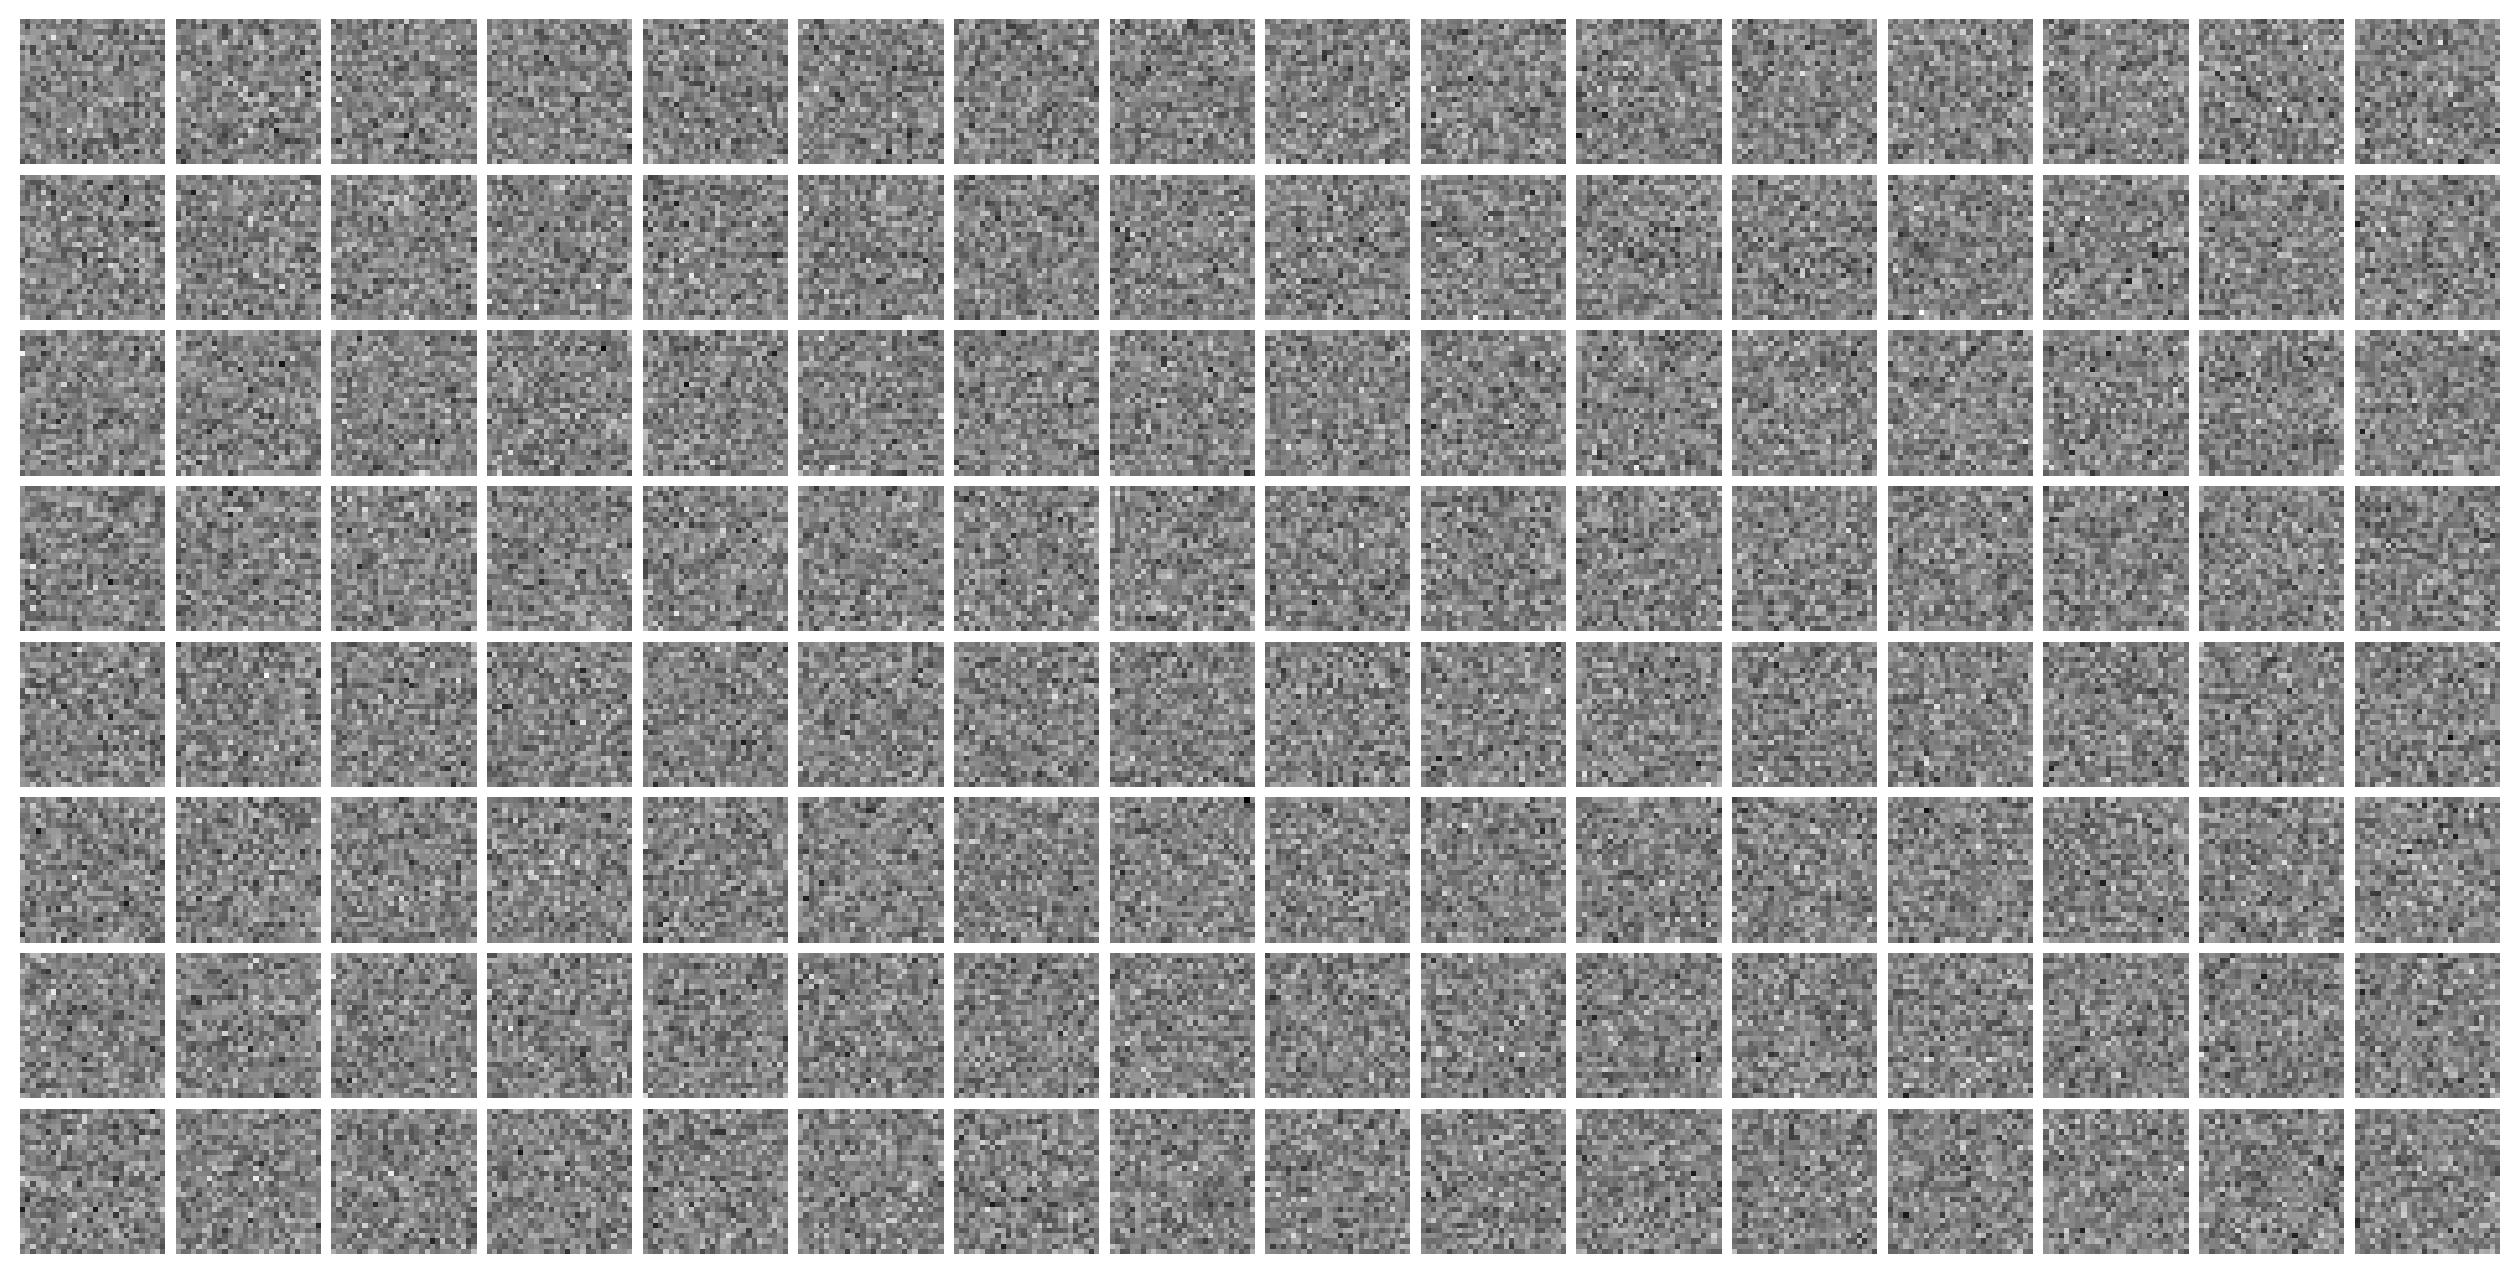

Epoch 1: 	
#####################################################	elapsed: 0.18s, reconstruction error: 30.73
Epoch 2: 	
#####

/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/ipykernel_41889/1604615279.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


################################################	elapsed: 0.19s, reconstruction error: 24.10
Epoch 3: 	
#####################################################	elapsed: 0.17s, reconstruction error: 20.70
Epoch 4: 	
#####################################################	elapsed: 0.17s, reconstruction error: 18.66
Epoch 5: 	
#####################################################	elapsed: 0.18s, reconstruction error: 17.14
Epoch 6: 	
#####################################################	elapsed: 0.17s, reconstruction error: 15.99
Epoch 7: 	
#####################################################	elapsed: 0.17s, reconstruction error: 15.24
Epoch 8: 	
#####################################################	elapsed: 0.17s, reconstruction error: 14.49
Epoch 9: 	
#####################################################	elapsed: 0.18s, reconstruction error: 13.94
Epoch 10: 	
#####################################################	elapsed: 0.17s, reconstruction error: 13.33
Epoch 11: 	
######################

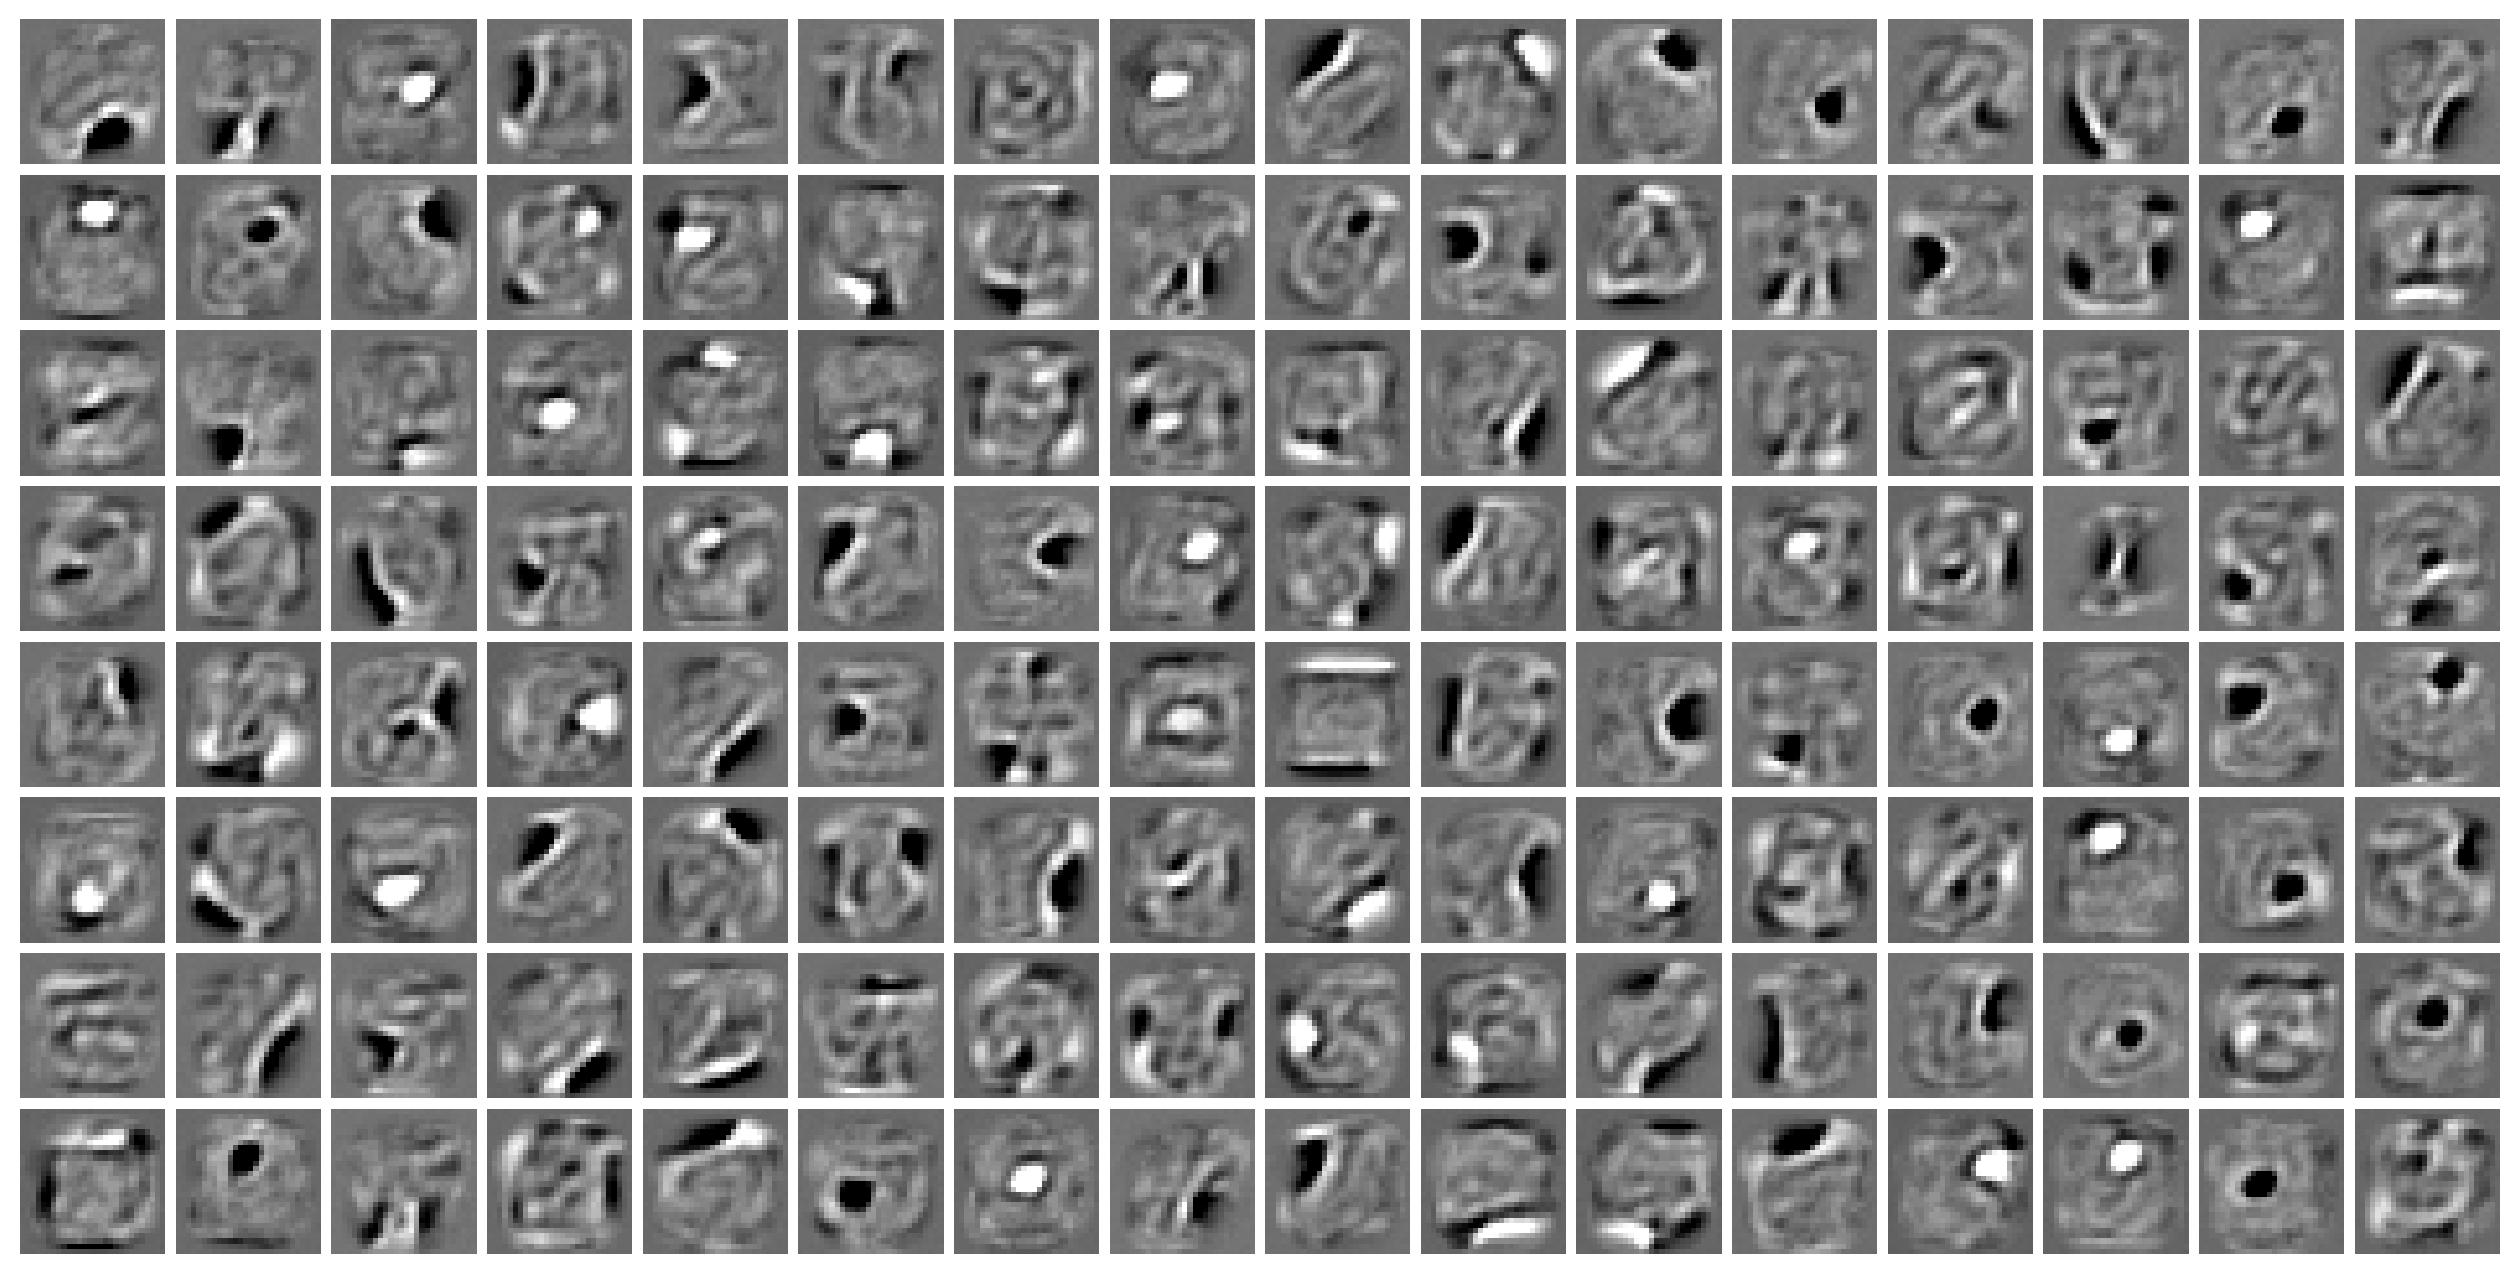

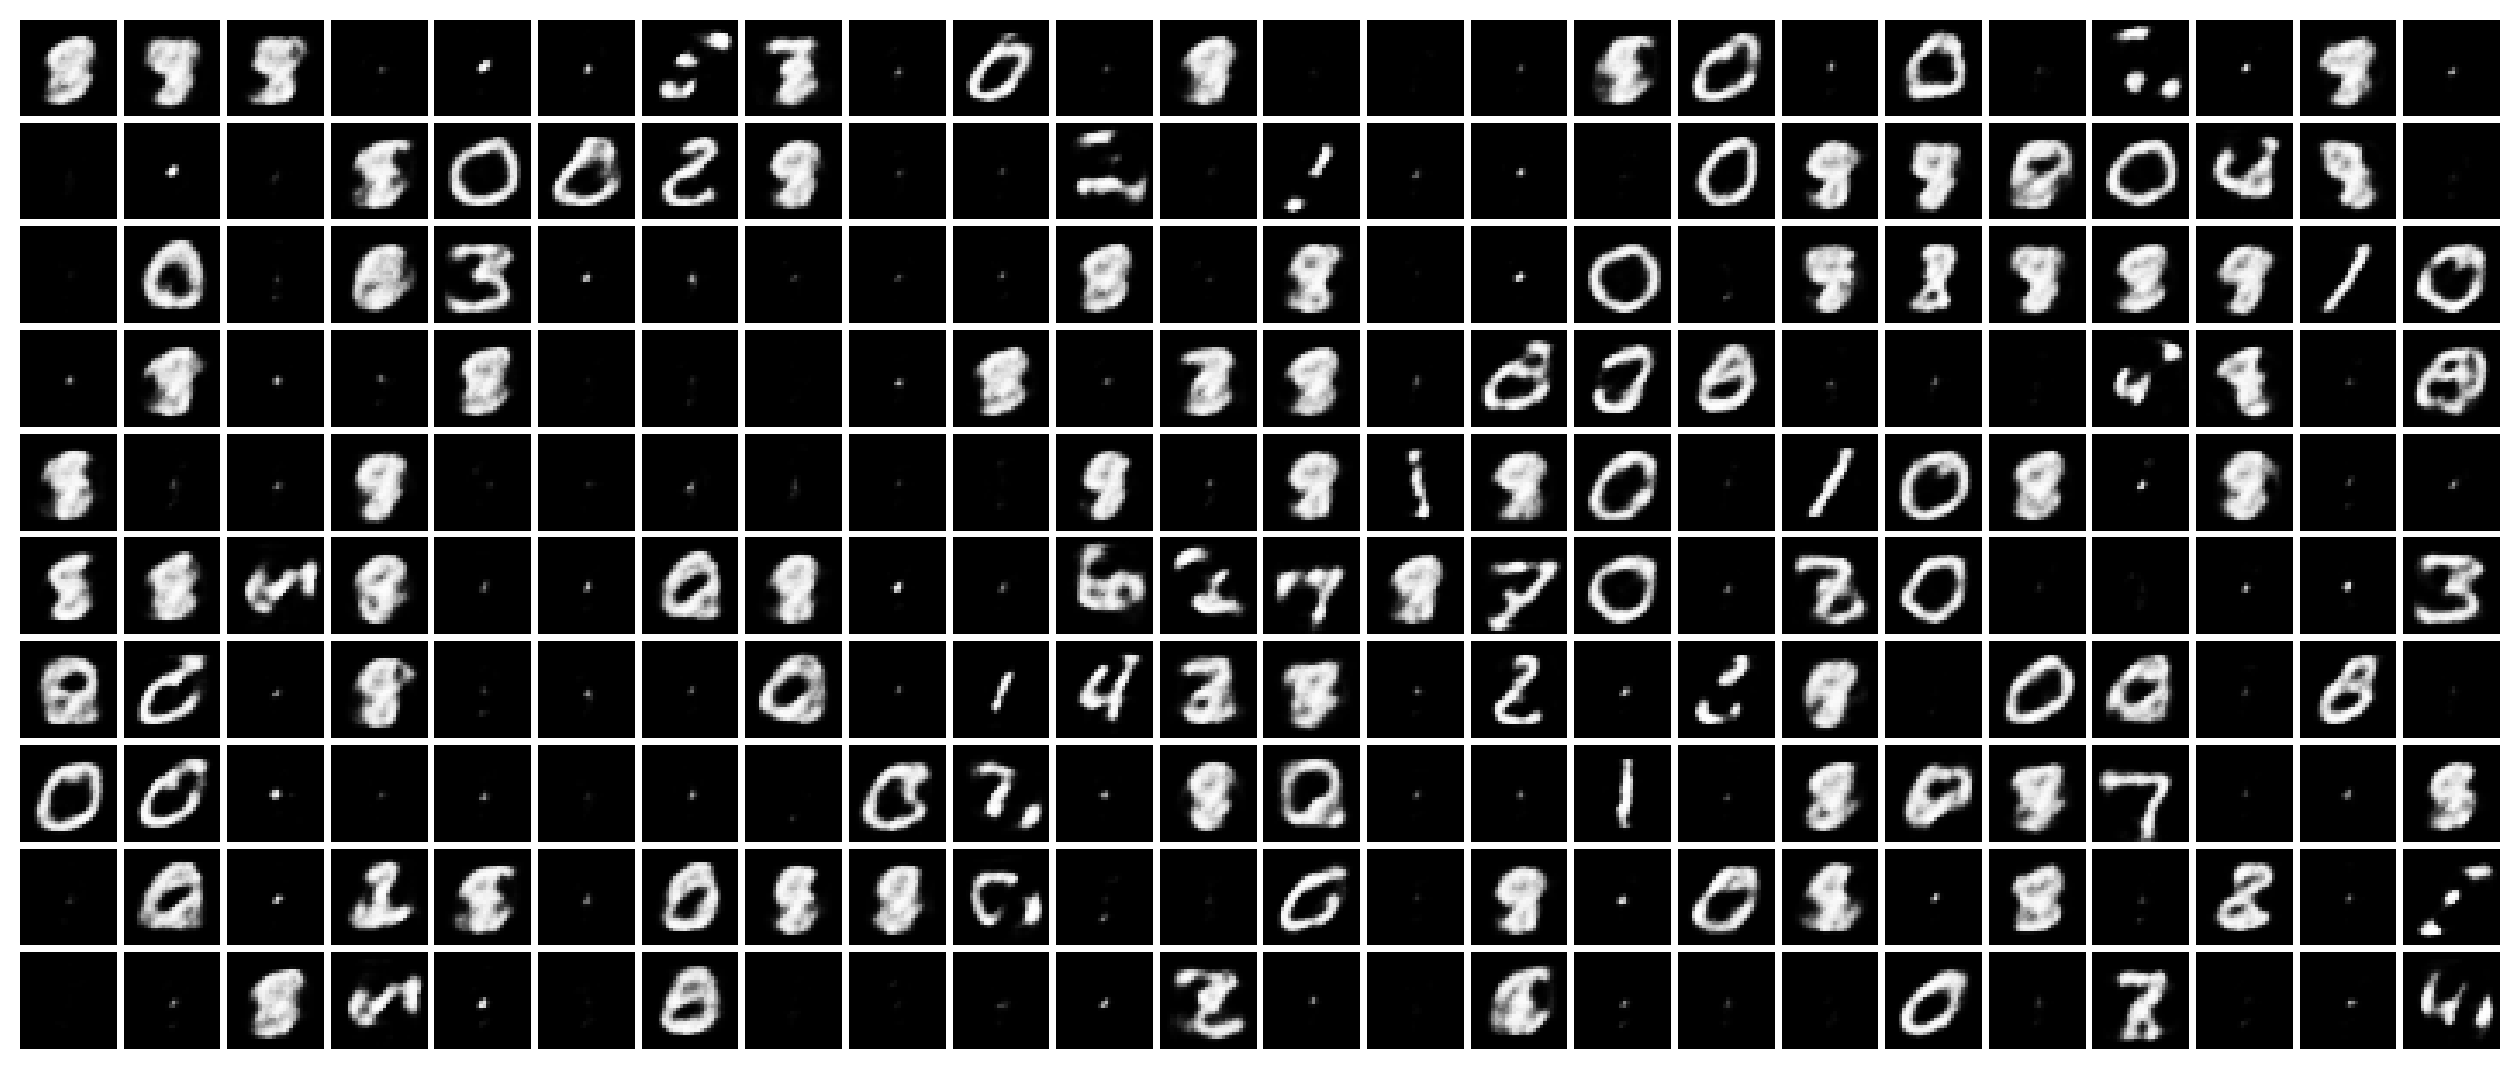

In [28]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

CDK_LEARNING_RATE: float = 0.1

rbm = RestrictedBoltzmanMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, CDK_LEARNING_RATE)
draw_filters(rbm)

run_training(rbm, dataset, monitoring_set, BATCH_SIZE, EPOCHS_COUNT, cdk)

draw_filters(rbm)
draw_samples(rbm, monitoring_set[:10*24])

## PCD Training

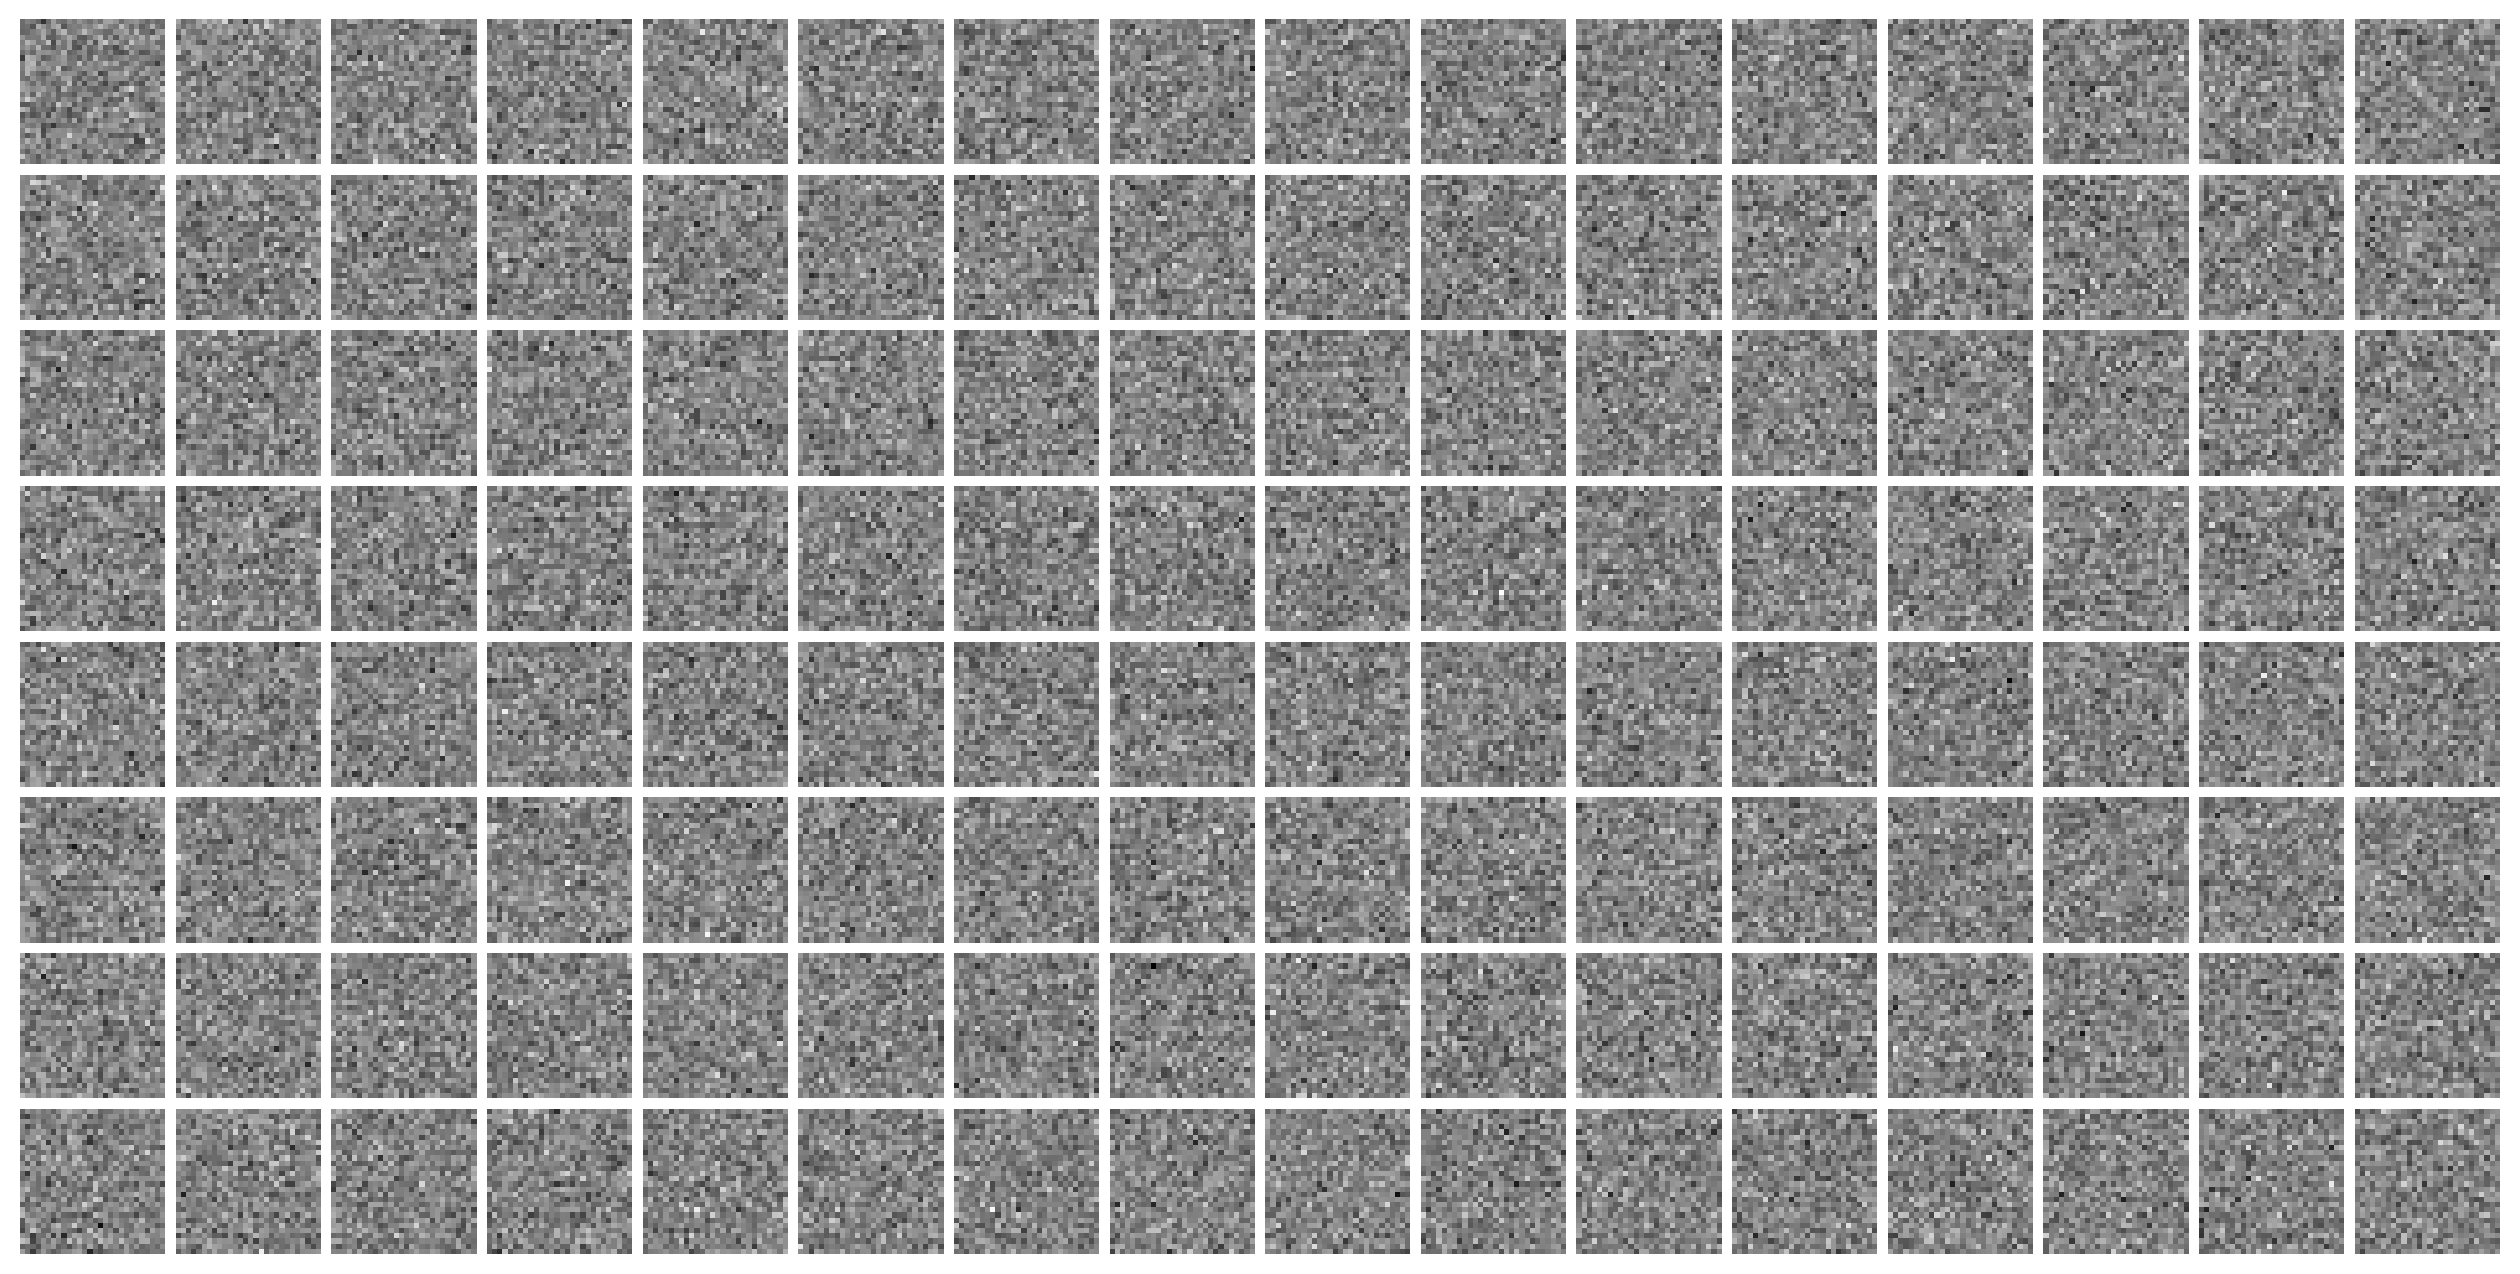

Epoch 1: 	
#####################################################	elapsed: 0.17s, reconstruction error: 73.61
Epoch 2: 	
###########

/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/ipykernel_41889/1604615279.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


##########################################	elapsed: 0.18s, reconstruction error: 55.67
Epoch 3: 	
#####################################################	elapsed: 0.17s, reconstruction error: 43.16
Epoch 4: 	
#####################################################	elapsed: 0.16s, reconstruction error: 38.56
Epoch 5: 	
#####################################################	elapsed: 0.18s, reconstruction error: 35.36
Epoch 6: 	
#####################################################	elapsed: 0.18s, reconstruction error: 33.24
Epoch 7: 	
#####################################################	elapsed: 0.18s, reconstruction error: 31.16
Epoch 8: 	
#####################################################	elapsed: 0.17s, reconstruction error: 29.73
Epoch 9: 	
#####################################################	elapsed: 0.17s, reconstruction error: 28.65
Epoch 10: 	
#####################################################	elapsed: 0.17s, reconstruction error: 28.40
Epoch 11: 	
############################

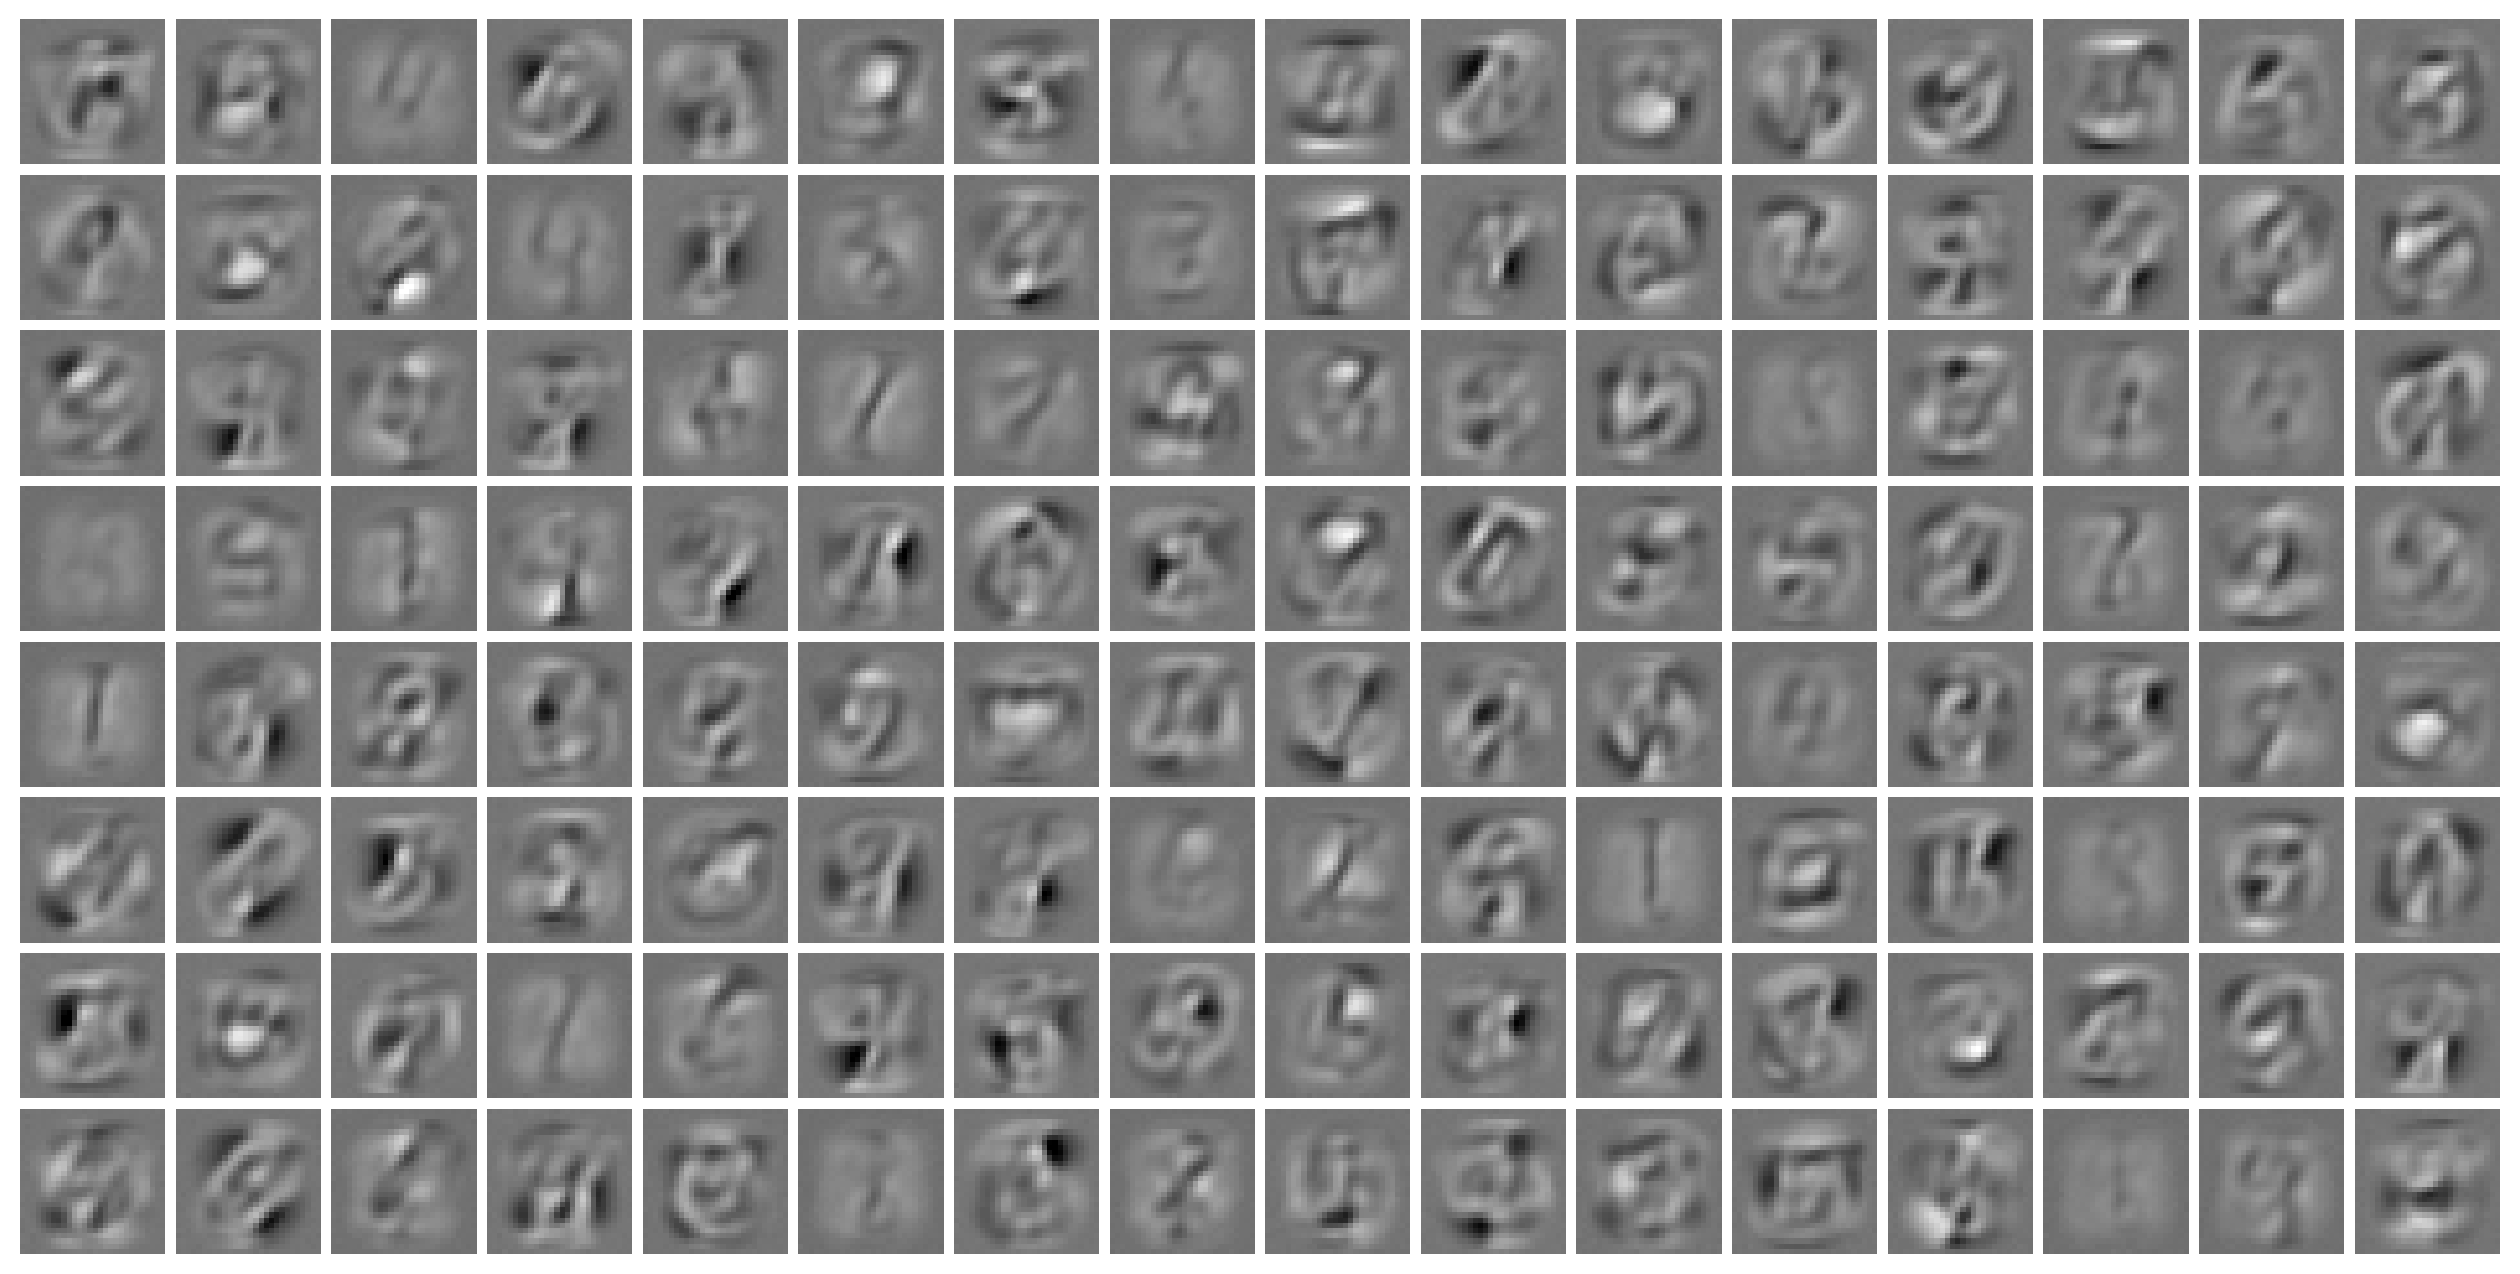

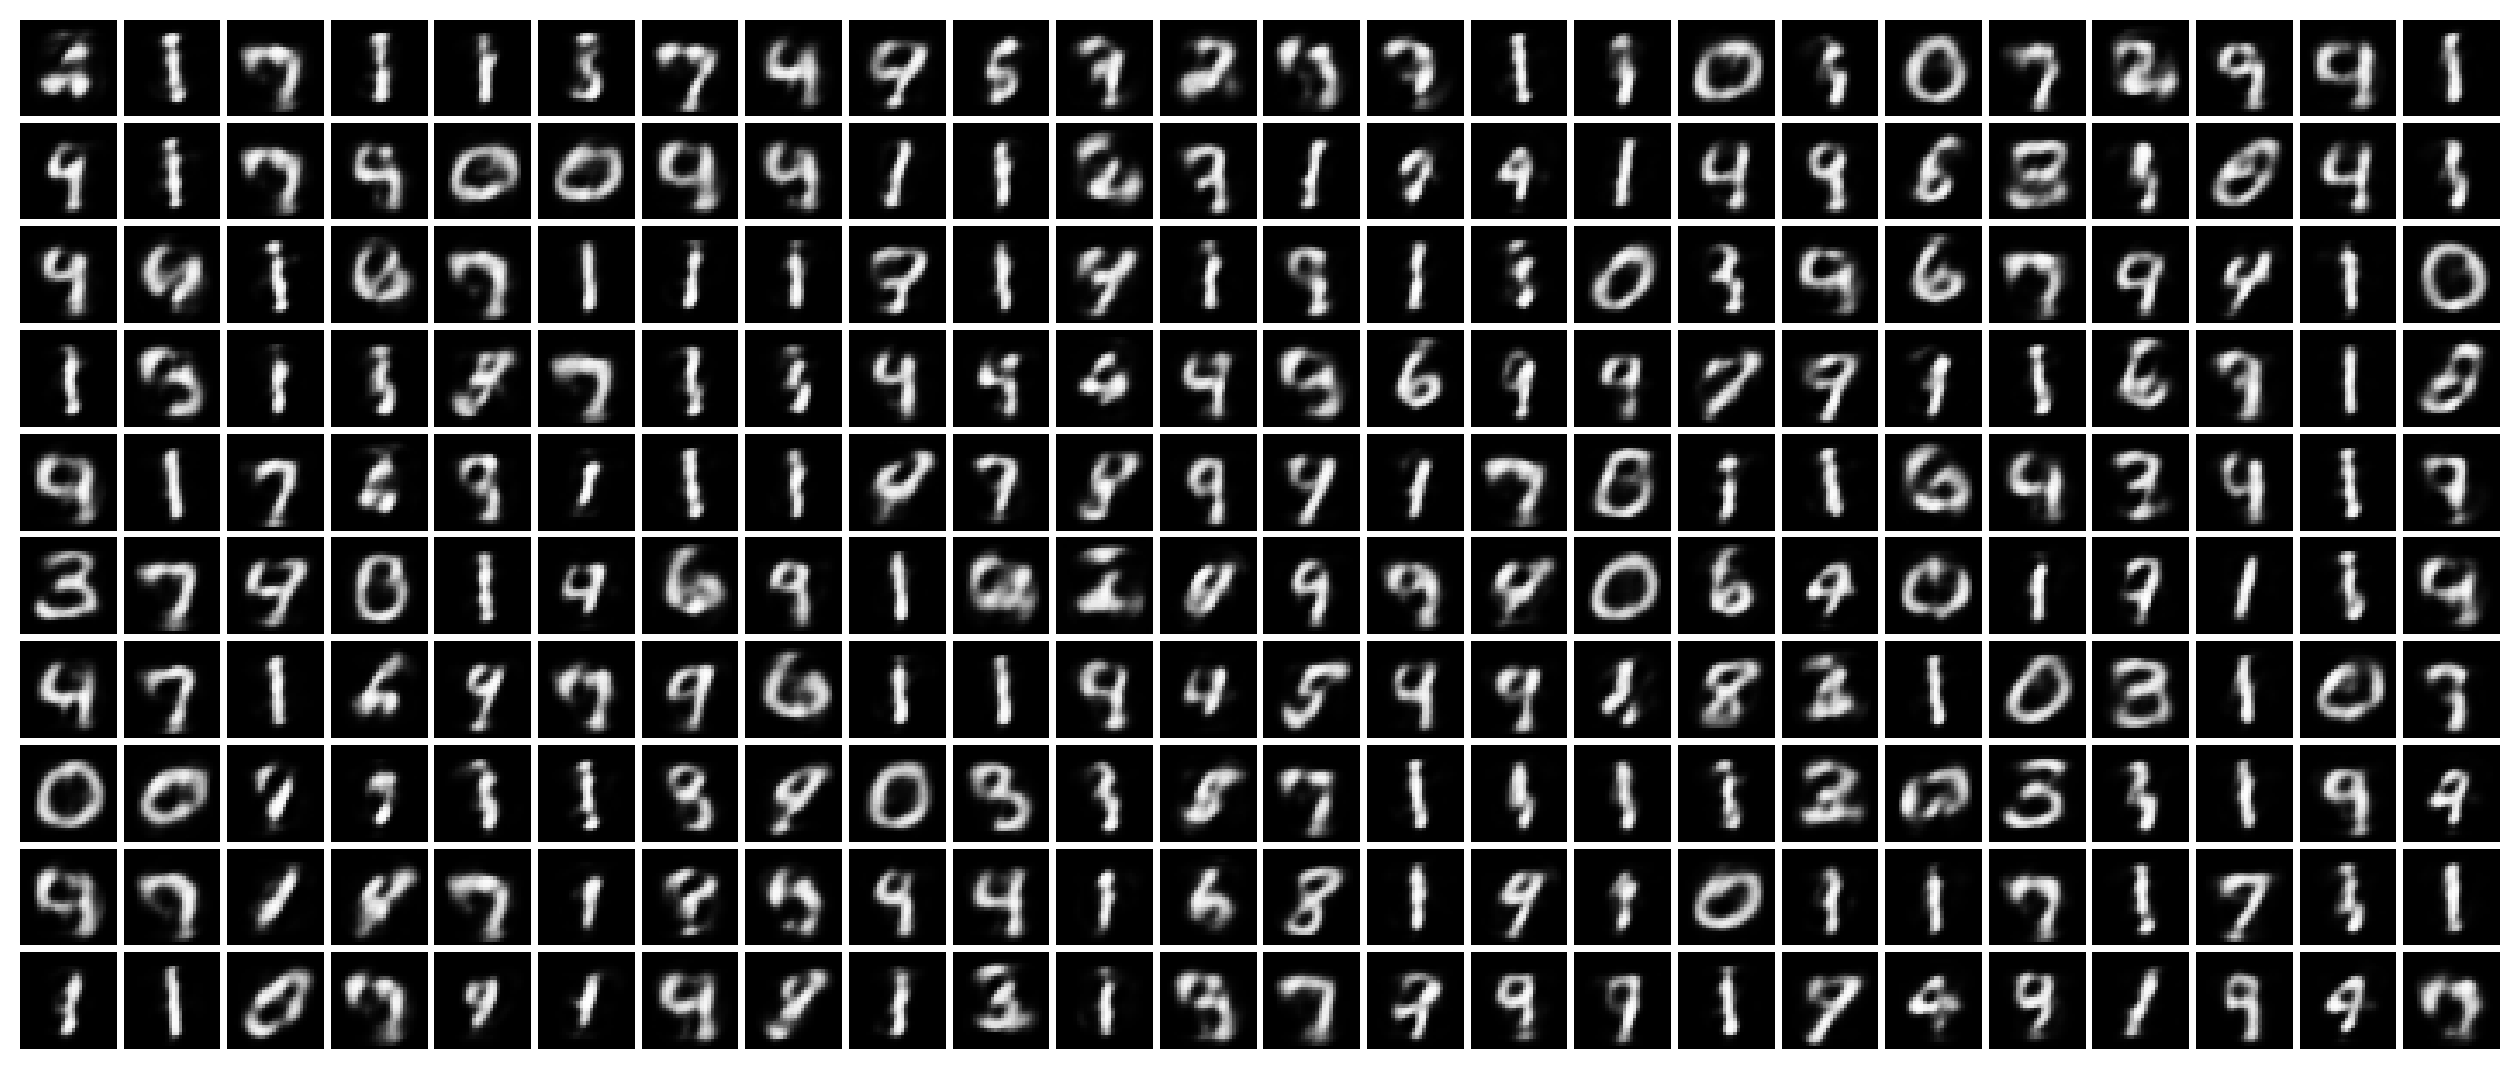

In [29]:
BATCH_SIZE = 128
EPOCHS_COUNT = 50

PCD_PARTICLES_COUNT = 128
PCD_LEARNING_RATE = 0.01

rbm_pcd = RestrictedBoltzmanMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, PCD_LEARNING_RATE, PCD_PARTICLES_COUNT)
draw_filters(rbm_pcd)

run_training(rbm_pcd, dataset, monitoring_set, BATCH_SIZE, EPOCHS_COUNT, pcd)

draw_filters(rbm_pcd)
draw_samples(rbm_pcd, monitoring_set[:10*24])

## Additional links

* [YouTube | Hugo Larochelle | Neural networks [5.6] : Restricted Boltzmann machine - persistent CD](https://www.youtube.com/watch?v=S0kFFiHzR8M&list=PL4L648fEOvtpPeg6XLcWCchNgpqfozGBD&index=6)